In [1]:
import numpy as np
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import traceback

from pathlib import Path
from IPython.display import clear_output
from seppy.util import resample_df
from solo_epd_loader import epd_load
from matplotlib.colors import LogNorm

from aipad.pad_imputation import (
    convert_to_bool_coverage, load_wind_event, coverage_overlap, 
    load_random_file, pad_histogram
)

from aipad.spacecrafts import SoloConstants, WindConstants

solo = SoloConstants()
wind = WindConstants()

### Generate coverages

In [6]:
import logging
filehandler = logging.FileHandler(filename="./logs/solo_cov.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

bin_width_deg = 1
time_avg_min = 1
root_path = Path(".")
data_path = root_path / "data" / "datafiles"
save_path = Path(".") / "data" / "coverages" / f"{time_avg_min}min_{bin_width_deg}deg"

data_path.mkdir(exist_ok=True)
save_path.mkdir(exist_ok=True)

max_days = (solo.mission_end - solo.mission_start).days
name = solo.name

try:
    start = int(sys.argv[1])
except (IndexError, ValueError):
    start = 0

logging.info(f"Run start: {start}")

for i in range(start, max_days):
    logging.info(f"Day {i}")
    
    date = solo.mission_start + dt.timedelta(days=i)
    logging.info(f"Forming {name} coverages from date {date}")
    try:
        df, df_rtn, df_hci, energies_dict, metadata_dict = epd_load("ept", startdate=date, 
                                                                    level="l3", autodownload=True,
                                                                    path=str(data_path), pos_timestamp="start")

        if (len(df.index) // 60) < 12:
            logging.info(f"Day {i}: Data file not long enough to generate 12 hour coverage, skipping...")
            continue
        
        # if more than 20 % of data is missing, skip
        if np.mean(np.isnan(df.to_numpy())) > 0.20:
            logging.info(f"Day {i}: Over 20 % of the data is missing, skipping...")
            continue
        
        if time_avg_min > 1:
            df = resample_df(df, resample=str(time_avg_min) + "min", pos_timestamp="start")
        elif time_avg_min == 1:
            pass
        else:
            raise ValueError("SolO cadence is 1min, unwise to average less!")
        
        ind = pd.MultiIndex.from_product([solo.sectors, ["min", "center", "max"]])
        df_cov = pd.DataFrame(index=df.index, columns=ind)

        for direction, pa_col, pa_sigma_col in zip(solo.sectors, solo.pitch_angle_mu_columns, 
                                                    solo.pitch_angle_sigma_columns):
            df_cov[(direction, "center")] = df[pa_col]
            df_cov[(direction, "min")] = df[pa_col] - df[pa_sigma_col]
            df_cov[(direction, "max")] = df[pa_col] + df[pa_sigma_col]

        X1, Y1, solo_cov = convert_to_bool_coverage(df_cov, sc=solo, bin_width_deg=bin_width_deg)

        # Generate 2 random 12 hour coverages
        
        for j in range(1, 3):
            random_start = np.random.randint(0, len(solo_cov) - 12*60//time_avg_min)
            start_dt = (date+dt.timedelta(minutes=random_start*time_avg_min))
            cov = solo_cov[random_start:random_start+12*60//time_avg_min]
            logging.info(f"Generated 12 hr coverage with shape {cov.shape}")
            np.save(save_path / f"solo_{start_dt.strftime("%Y%m%d_%H%M%S")}_{time_avg_min}min_{bin_width_deg}deg", cov)

    except UnboundLocalError:
        logging.info(f"No data was found, skipping...")

    clear_output()

01/31/2026 12:28:39 Day 1514
01/31/2026 12:28:39 Forming SolO coverages from date 2025-02-23 00:00:00


solo_L3_epd-ept-1min_20250223_V01.cdf: 0.00B [00:00, ?B/s]


KeyboardInterrupt: 

In [ ]:
df["Pitch_Angle_Sigma_S"]

### Generate full and reduced intensity histograms, save intensity data

In [ ]:
import logging
filehandler = logging.FileHandler(filename="./logs/histogram_forming.log", encoding="utf-8")
streamhandler = logging.StreamHandler(sys.stdout)
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s', datefmt='%m/%d/%Y %H:%M:%S', handlers=[filehandler, streamhandler], force=True)

year = 2012

energy_channel = 3
bin_width_deg = 1
time_avg_min = 1

data_path = Path("./data/datafiles")
cov_path = Path("./data/coverages") / f"{time_avg_min}min_{bin_width_deg}deg"
event_path = Path("./data/event_lists")

save_path = Path("./data/intensities") / f"{time_avg_min}min_{bin_width_deg}deg"
save_path.mkdir(exist_ok=True)

# full_path = Path("./data/intensities/full") / f"{time_avg_min}min_{bin_width_deg}deg"
# reduced_path = Path("./data/intensities/reduced") / f"{time_avg_min}min_{bin_width_deg}deg"
# full_path.mkdir(exist_ok=True)
# reduced_path.mkdir(exist_ok=True)

try:
    df = pd.read_csv(event_path / f"wind_events_{year}.csv", delimiter=",")

    df_ = df

    for index, data in df_.iterrows():
        solo_cov_bool = load_random_file(cov_path)
        
        onset_dt = pd.to_datetime(df.iloc[index,1]) + pd.to_timedelta(df.iloc[index,2])
        if onset_dt < dt.datetime(2012, 8, 2):  # TODO: "saving" progress
            continue
        start = onset_dt - pd.Timedelta(hours=2)
        end = onset_dt + pd.Timedelta(hours=10)

        wind_event = load_wind_event(str(data_path), "Wind 3DP", start, end, "e", channels=energy_channel, averaging=f"{time_avg_min}min")
        wind_cov = wind_event.coverage
        X, Y, wind_cov_bool = convert_to_bool_coverage(wind_cov, wind, bin_width_deg=bin_width_deg)

        #cov_arr, reshaped = coverage_overlap(solo_cov_bool, wind_cov_bool)
        # TODO: for now, just skip if there's a shape mismatch. Need to think this through
        try:
            assert solo_cov_bool.shape == wind_cov_bool.shape
        except AssertionError:
            clear_output()
            logging.info(f"Coverage shape mismatch: SolO {solo_cov_bool.shape}, Wind {wind_cov_bool.shape} ({onset_dt})")
            continue

        cov_arr = solo_cov_bool & wind_cov_bool
        
        hist = pad_histogram(wind, wind_event.I_data, wind_cov, bin_width_deg)
        reduced_hist = np.where(cov_arr == True, hist, np.nan)

        logging.info(f"{hist.shape}, {reduced_hist.shape}")
        np.savez(save_path / f"Wind_{onset_dt.strftime("%Y%m%d-%H%M%S")}_{time_avg_min}min_{bin_width_deg}deg", 
                 allow_pickle=False, full=hist, reduced=reduced_hist, intensity_data=wind_event.I_data, times=wind_event.I_times)
        
        # TODO metadata (spacecraft, instrument, averaging, channels etc.)
        clear_output()
        logging.info(f"Histogram formed successfully ({onset_dt})")

except FileNotFoundError:
    logging.info(f"No data found for given year! ({year})")

01/13/2026 14:09:37 Histogram formed successfully (2012-08-31 20:47:39.516000)
Input was Wind, using Wind.
Spacecraft: Wind
Instrument: 3DP. Species: e. Channels: 3.
01/13/2026 14:09:40 WARNING: 
No columns with uncertainties automatically detected! You might need to provide them manually via the 'cols_unc' parameter. Please report this behaviour if you think it should work automatically.


01/13/2026 14:09:40 WARNING: Wind/3DP: The energy values in the metadata are now provided as MeV (previously eV)! Also DE is now 2*delta_e (previously just delta_e). Please adapt your scripts accordingly!

01/13/2026 14:09:43 WARNING: 
No columns with uncertainties automatically detected! You might need to provide them manually via the 'cols_unc' parameter. Please report this behaviour if you think it should work automatically.


01/13/2026 14:09:43 WARNING: Wind/3DP: The energy values in the metadata are now provided as MeV (previously eV)! Also DE is now 2*delta_e (previously just delta_e). Please

KeyboardInterrupt: 

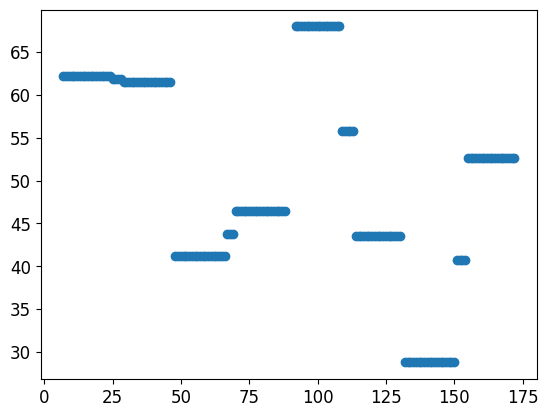

In [8]:
fig, axs = plt.subplots()

plt.scatter(np.arange(len(hist[100])), hist[100])

In [10]:
wind_event.coverage

P0                               P1             \
                              min     center        max        min     center   
Epoch                                                                           
2012-08-31 18:48:35.534  5.722113  16.972113  28.222113  19.201162  30.451162   
2012-08-31 18:49:35.534  4.443836  15.693836  26.943836  20.092354  31.342354   
2012-08-31 18:50:35.534  4.632547  15.882547  27.132547  19.948360  31.198360   
2012-08-31 18:51:35.534  4.652815  15.902815  27.152815  19.929544  31.179544   
2012-08-31 18:52:35.534  4.586166  15.836166  27.086166  19.976440  31.226440   
...                           ...        ...        ...        ...        ...   
2012-09-01 06:43:35.534  0.000000   6.685687  17.935686  23.917126  35.167126   
2012-09-01 06:44:35.534  0.000000   6.626003  17.876003  26.717308  37.967308   
2012-09-01 06:45:35.534  2.269046  13.519046  24.769047  28.859367  40.109367   
2012-09-01 06:46:35.534  2.205618  13.455618  24.705618  27.265594  38.515594   
2012-09-01 06:47:35.534  1.251603  12.501603  23.751602  26.554272  37.804272   

                                           P2                        \
                               max        min     center        max   
Epoch                                                                 
2012-08-31 18:48:35.534  41.701164  45.352013  56.602013  67.852013   
2012-08-31 18:49:35.534  42.592354  44.127033  55.377033  66.627029   
2012-08-31 18:50:35.534  42.448360  44.001942  55.251942  66.501938   
2012-08-31 18:51:35.534  42.429543  44.810883  56.060883  67.310883   
2012-08-31 18:52:35.534  42.476440  44.226971  55.476971  66.726974   
...                            ...        ...        ...        ...   
2012-09-01 06:43:35.534  46.417126  41.686134  52.936134  64.186134   
2012-09-01 06:44:35.534  49.217308  44.594452  55.844452  67.094452   
2012-09-01 06:45:35.534  51.359367  49.885406  61.135406  72.385406   
2012-09-01 06:46:35.534  49.765594  46.243084  57.493084  68.743088   
2012-09-01 06:47:35.534  49.054272  43.878822  55.128822  66.378822   

                                P3  ...          P4          P5              \
                               min  ...         max         min      center   
Epoch                               ...                                       
2012-08-31 18:48:35.534  67.944908  ...  111.430832  112.205101  123.455101   
2012-08-31 18:49:35.534  66.849716  ...  112.323372  113.353989  124.603989   
2012-08-31 18:50:35.534  67.326355  ...  112.683632  113.485886  124.735886   
2012-08-31 18:51:35.534  67.637924  ...  112.291672  112.730591  123.980591   
2012-08-31 18:52:35.534  67.338638  ...  112.600204  113.311462  124.561462   
...                            ...  ...         ...         ...         ...   
2012-09-01 06:43:35.534  67.369858  ...  113.311050  113.559448  124.809448   
2012-09-01 06:44:35.534  65.968971  ...  113.822670  118.382416  129.632416   
2012-09-01 06:45:35.534  66.145554  ...  113.193497  115.101669  126.351669   
2012-09-01 06:46:35.534  66.123436  ...  113.712677  115.153313  126.403313   
2012-09-01 06:47:35.534  65.908333  ...  114.328445  113.470863  124.720863   

                                             P6                          \
                                max         min      center         max   
Epoch                                                                     
2012-08-31 18:48:35.534  134.705109  136.020905  147.270905  158.520905   
2012-08-31 18:49:35.534  135.853989  134.510696  145.760696  157.010696   
2012-08-31 18:50:35.534  135.985886  134.307739  145.557739  156.807739   
2012-08-31 18:51:35.534  135.230591  134.742523  145.992523  157.242523   
2012-08-31 18:52:35.534  135.811462  134.557983  145.807983  157.057983   
...                             ...         ...         ...         ...   
2012-09-01 06:43:35.534  136.059448  131.950516  143.200516  154.450516   
2012-09-01 06:44:35.534  140.882416  130.593